# Cuts and tags

* N molecules are cut with the same breakpoints

* Each molecule is labeled with a tag with M possible values. The frequencies of the tags is not uniform: $p_1, ..., p_M$

* How many unique tags do we expect to see?

* The probability of missing the i-th tag is $(1-p_i)^N$.

* Then, the probability to see the i-th tag is $1-(1-p_i)^N$.

* The expected number of unique tags observed is 

$$\sum_{i=1}^M 1 - (1-p_i)^N = M-\sum_{i=1}^M (1-p_i)^N = \psi(N)$$

* Given an expectation of unique tags and a vector of probabilities, we want to find $N = \psi^{-1}(e)$.

* The proportion of repeated tags is 

$$\rho(e) = \frac{N - e}{N}$$

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import brentq

import matplotlib.pyplot as plt

In [2]:
def func(N, p):
    """
    p: numpy array of probabilities
    N: number of independent trials
    """
    return np.sum(1 - (1 - p) ** N)


def find_N(p, target):
    """
    p: numpy array of probabilities
    target: target value for the sum
    """
    # Define a function that we want to find the root of
    def objective(N):
        return func(N, p) - target
    
    # Use brentq to find the root of the objective function
    N_solution = brentq(objective, 1, 1e6)  # Search for N in the range [1, 1e6]
    
    return N_solution

In [5]:
# Example usage

k = 1024
p = np.ones(k) / k  # Uniform probabilities

target = 2  # Target value

N_solution = find_N(p, target)

print(f"Estimated N: {N_solution}")
print(f"Estimated proportion of repeats: {(N_solution - target) / N_solution:.4f}")

Estimated N: 2.000977995265819
Estimated proportion of repeats: 0.0005


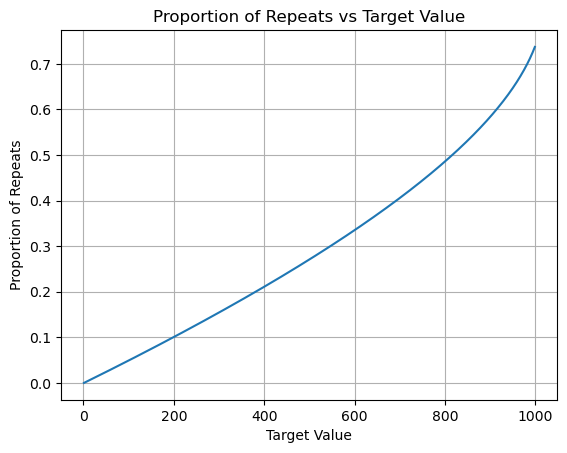

In [4]:
# Plotting the proportion of repeats for a range of target values

targets = np.arange(1, 1000)
N_solutions = [find_N(p, target) for target in targets]
proportions_repeats = [(N - target) / N for N, target in zip(N_solutions, targets)]
plt.plot(targets, proportions_repeats)
plt.xlabel('Target Value')
plt.ylabel('Proportion of Repeats')
plt.title('Proportion of Repeats vs Target Value')
plt.grid()
plt.show()